<a href="https://colab.research.google.com/github/padmarajanandhu-code/Case_study_sql/blob/main/Customer_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [5]:
train_df = pd.read_csv("/content/Training_data.csv")
test_df = pd.read_csv("/content/Testing_data.csv")

In [6]:
train_df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,9509-MPYOD,Female,0,No,No,35,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,7746-AWNQW,Female,0,No,No,28,No,No phone service,DSL,No,...,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.4,No
2,2208-UGTGR,Male,0,No,No,56,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,4884-LEVMQ,Male,0,Yes,No,39,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790,No
4,6682-VCIXC,Female,0,Yes,Yes,43,No,No phone service,DSL,NaN,...,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.6,No
5,7048-GXDAY,Male,0,No,No,39,Yes,Yes,Fiber optic,Yes,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,106.40,4040.65,No
6,4697-LUPSU,Male,0,Yes,Yes,2,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.20,34.75,No
7,2432-TFSMK,Male,0,No,No,18,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,No,One year,Yes,Credit card (automatic),89.60,1633,No
8,2027-WKXMW,Female,0,Yes,No,63,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,108.75,6871.7,No
9,4826-TZEVA,Female,0,No,No,40,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,No,Credit card (automatic),74.80,NaN,No


In [7]:
train_df.shape

(5634, 21)

In [8]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5634 non-null   object 
 1   gender            5465 non-null   object 
 2   SeniorCitizen     5634 non-null   int64  
 3   Partner           5634 non-null   object 
 4   Dependents        5634 non-null   object 
 5   tenure            5634 non-null   int64  
 6   PhoneService      5634 non-null   object 
 7   MultipleLines     5634 non-null   object 
 8   InternetService   5634 non-null   object 
 9   OnlineSecurity    5465 non-null   object 
 10  OnlineBackup      5634 non-null   object 
 11  DeviceProtection  5634 non-null   object 
 12  TechSupport       5634 non-null   object 
 13  StreamingTV       5634 non-null   object 
 14  StreamingMovies   5634 non-null   object 
 15  Contract          5634 non-null   object 
 16  PaperlessBilling  5634 non-null   object 


#Missing values

In [9]:
train_df.isnull().sum()

,0
customerID,0
gender,169
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,169


In [10]:
(train_df == " ").sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [11]:
train_df.duplicated().sum()
# No duplicates

np.int64(0)

In [12]:
train_df['Churn'].value_counts()

,count
Churn,
No,4130
Yes,1504


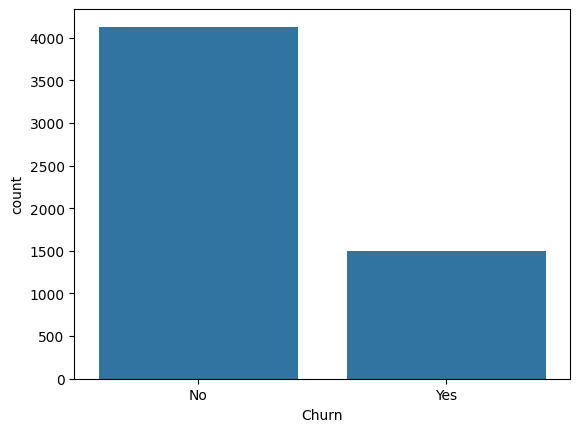

In [13]:
sns.countplot(x='Churn', data=train_df)
plt.show()

In [14]:
train_df['gender'].fillna(train_df['gender'].mode()[0], inplace=True)

train_df['OnlineSecurity'].fillna(train_df['OnlineSecurity'].mode()[0], inplace=True)

/tmp/ipykernel_11005/3769700939.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['gender'].fillna(train_df['gender'].mode()[0], inplace=True)
/tmp/ipykernel_11005/3769700939.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(valu

In [15]:
train_df['TotalCharges'] = pd.to_numeric(train_df['TotalCharges'], errors='coerce')



In [16]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5634 non-null   object 
 1   gender            5634 non-null   object 
 2   SeniorCitizen     5634 non-null   int64  
 3   Partner           5634 non-null   object 
 4   Dependents        5634 non-null   object 
 5   tenure            5634 non-null   int64  
 6   PhoneService      5634 non-null   object 
 7   MultipleLines     5634 non-null   object 
 8   InternetService   5634 non-null   object 
 9   OnlineSecurity    5634 non-null   object 
 10  OnlineBackup      5634 non-null   object 
 11  DeviceProtection  5634 non-null   object 
 12  TechSupport       5634 non-null   object 
 13  StreamingTV       5634 non-null   object 
 14  StreamingMovies   5634 non-null   object 
 15  Contract          5634 non-null   object 
 16  PaperlessBilling  5634 non-null   object 


In [17]:
train_df['MonthlyCharges'].fillna(train_df['MonthlyCharges'].median(), inplace=True)

train_df['TotalCharges'].fillna(train_df['TotalCharges'].median(), inplace=True)

/tmp/ipykernel_11005/184769695.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['MonthlyCharges'].fillna(train_df['MonthlyCharges'].median(), inplace=True)
/tmp/ipykernel_11005/184769695.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col

In [18]:
train_df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [19]:
test_df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [20]:
test_df['TotalCharges'] = pd.to_numeric(test_df['TotalCharges'], errors='coerce')
test_df['TotalCharges'].fillna(test_df['TotalCharges'].median(), inplace=True)

/tmp/ipykernel_11005/804606391.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_df['TotalCharges'].fillna(test_df['TotalCharges'].median(), inplace=True)


In [21]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5634 non-null   object 
 1   gender            5634 non-null   object 
 2   SeniorCitizen     5634 non-null   int64  
 3   Partner           5634 non-null   object 
 4   Dependents        5634 non-null   object 
 5   tenure            5634 non-null   int64  
 6   PhoneService      5634 non-null   object 
 7   MultipleLines     5634 non-null   object 
 8   InternetService   5634 non-null   object 
 9   OnlineSecurity    5634 non-null   object 
 10  OnlineBackup      5634 non-null   object 
 11  DeviceProtection  5634 non-null   object 
 12  TechSupport       5634 non-null   object 
 13  StreamingTV       5634 non-null   object 
 14  StreamingMovies   5634 non-null   object 
 15  Contract          5634 non-null   object 
 16  PaperlessBilling  5634 non-null   object 


In [22]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1409 entries, 0 to 1408
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        1409 non-null   object 
 1   gender            1409 non-null   object 
 2   SeniorCitizen     1409 non-null   int64  
 3   Partner           1409 non-null   object 
 4   Dependents        1409 non-null   object 
 5   tenure            1409 non-null   int64  
 6   PhoneService      1409 non-null   object 
 7   MultipleLines     1409 non-null   object 
 8   InternetService   1409 non-null   object 
 9   OnlineSecurity    1409 non-null   object 
 10  OnlineBackup      1409 non-null   object 
 11  DeviceProtection  1409 non-null   object 
 12  TechSupport       1409 non-null   object 
 13  StreamingTV       1409 non-null   object 
 14  StreamingMovies   1409 non-null   object 
 15  Contract          1409 non-null   object 
 16  PaperlessBilling  1409 non-null   object 


In [23]:
test_df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [24]:
test_df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,1409.000000,1409.000000,1409.000000,1409.000000
mean,0.171753,31.428673,63.898013,2214.195848
std,0.377300,24.322161,30.282693,2242.072790
min,0.000000,0.000000,18.700000,18.800000
25%,0.000000,8.000000,30.100000,360.100000
50%,0.000000,27.000000,69.900000,1348.950000
75%,0.000000,54.000000,89.500000,3673.600000
max,1.000000,72.000000,118.600000,8547.150000


In [25]:
train_df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,5634.000000,5634.000000,5634.000000,5634.000000
mean,0.159744,32.606851,65.490034,2238.250728
std,0.366401,24.614976,29.020760,2216.294428
min,0.000000,0.000000,18.250000,18.850000
25%,0.000000,9.000000,44.000000,446.062500
50%,0.000000,29.000000,70.650000,1396.450000
75%,0.000000,56.000000,89.100000,3590.537500
max,1.000000,72.000000,118.750000,8684.800000


In [26]:
num_cols = train_df.select_dtypes(include=['int64', 'float64']).columns
cat_cols=train_df.select_dtypes(include=['object']).columns


In [27]:
cat_cols

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

In [28]:
num_cols

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

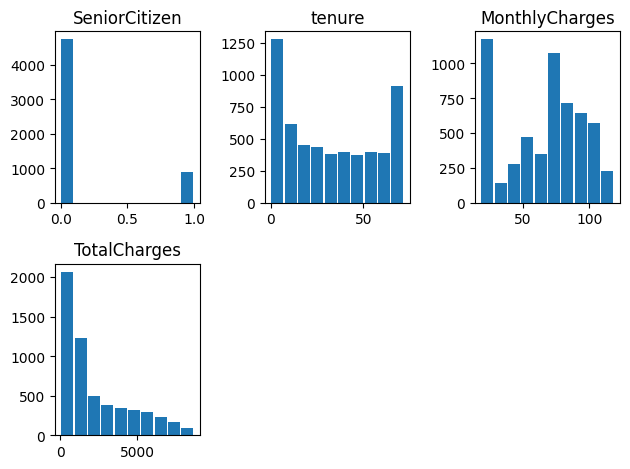

In [29]:
# Using iterative mehtods to plot lal histograms in ta single plot
for i, col in enumerate(num_cols,1):
  plt.subplot(2,3,i)
  plt.hist(train_df[col],rwidth=0.9)
  plt.title(col)

plt.tight_layout()
plt.show()

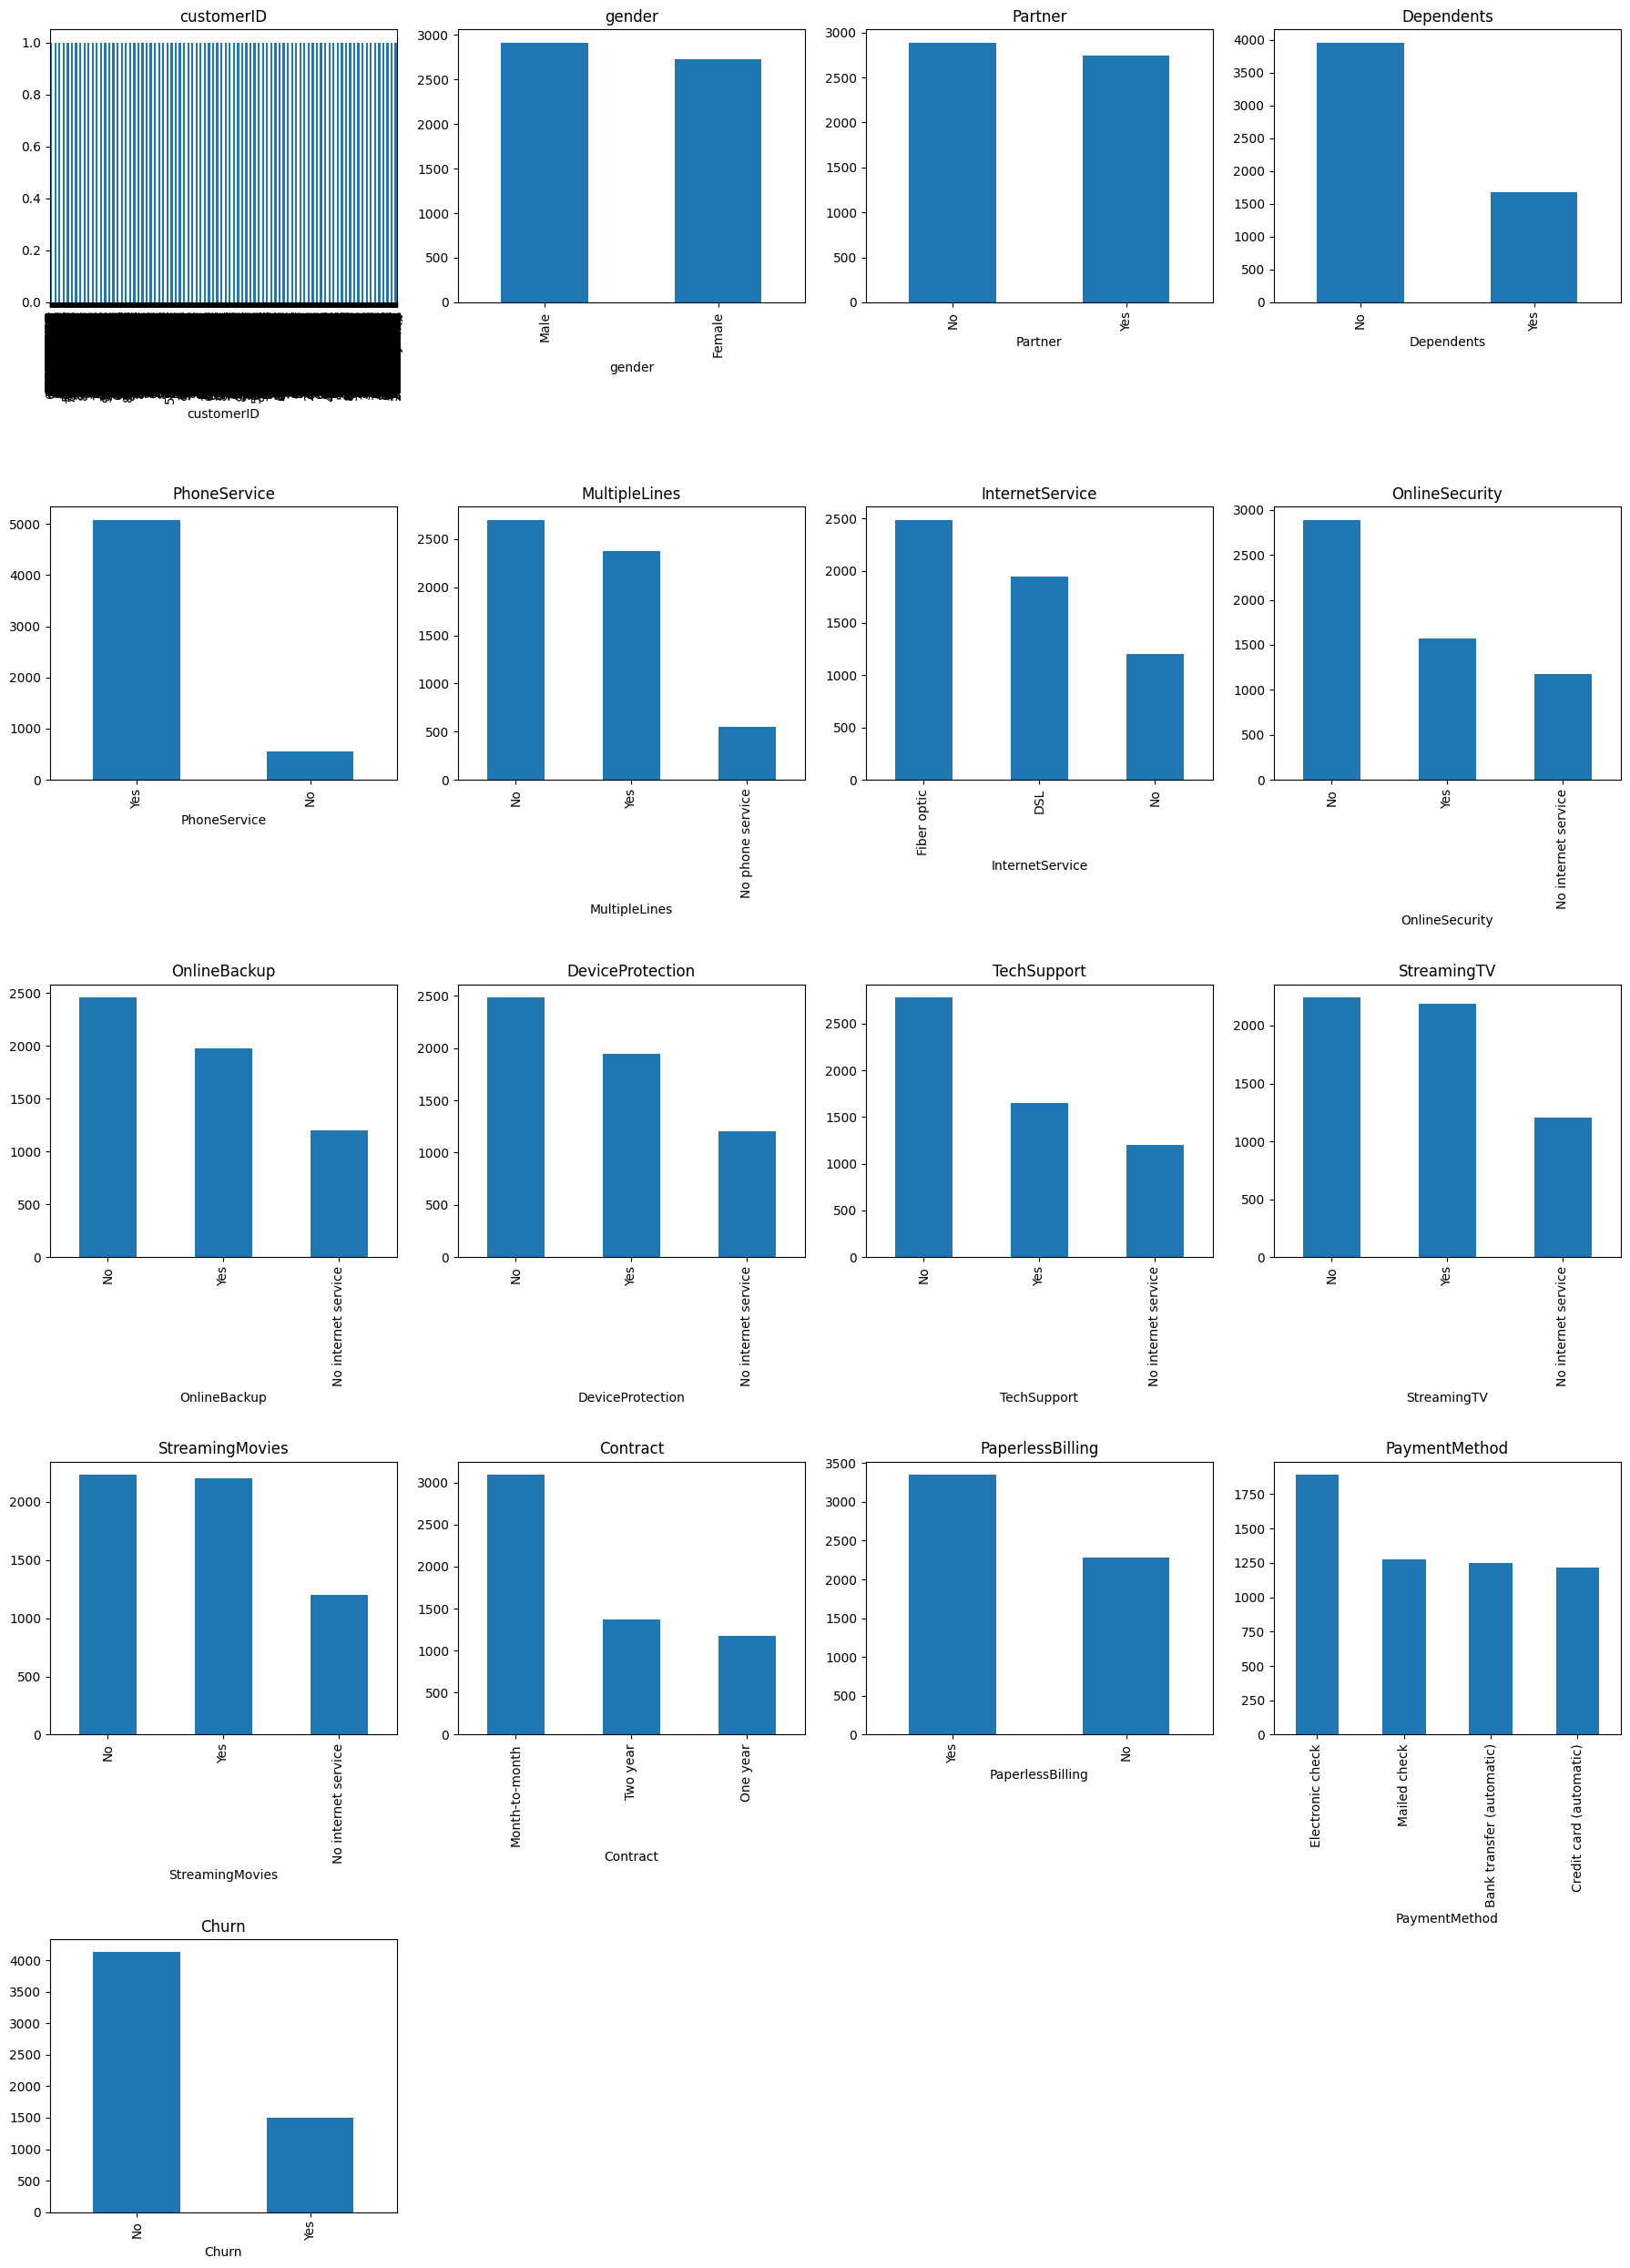

In [30]:
plt.figure(figsize=(18,25))

for i, col in enumerate(cat_cols, 1):

    plt.subplot(5, 4, i)

    train_df[col].value_counts().plot(kind='bar')

    plt.title(col)

plt.tight_layout()

plt.show()

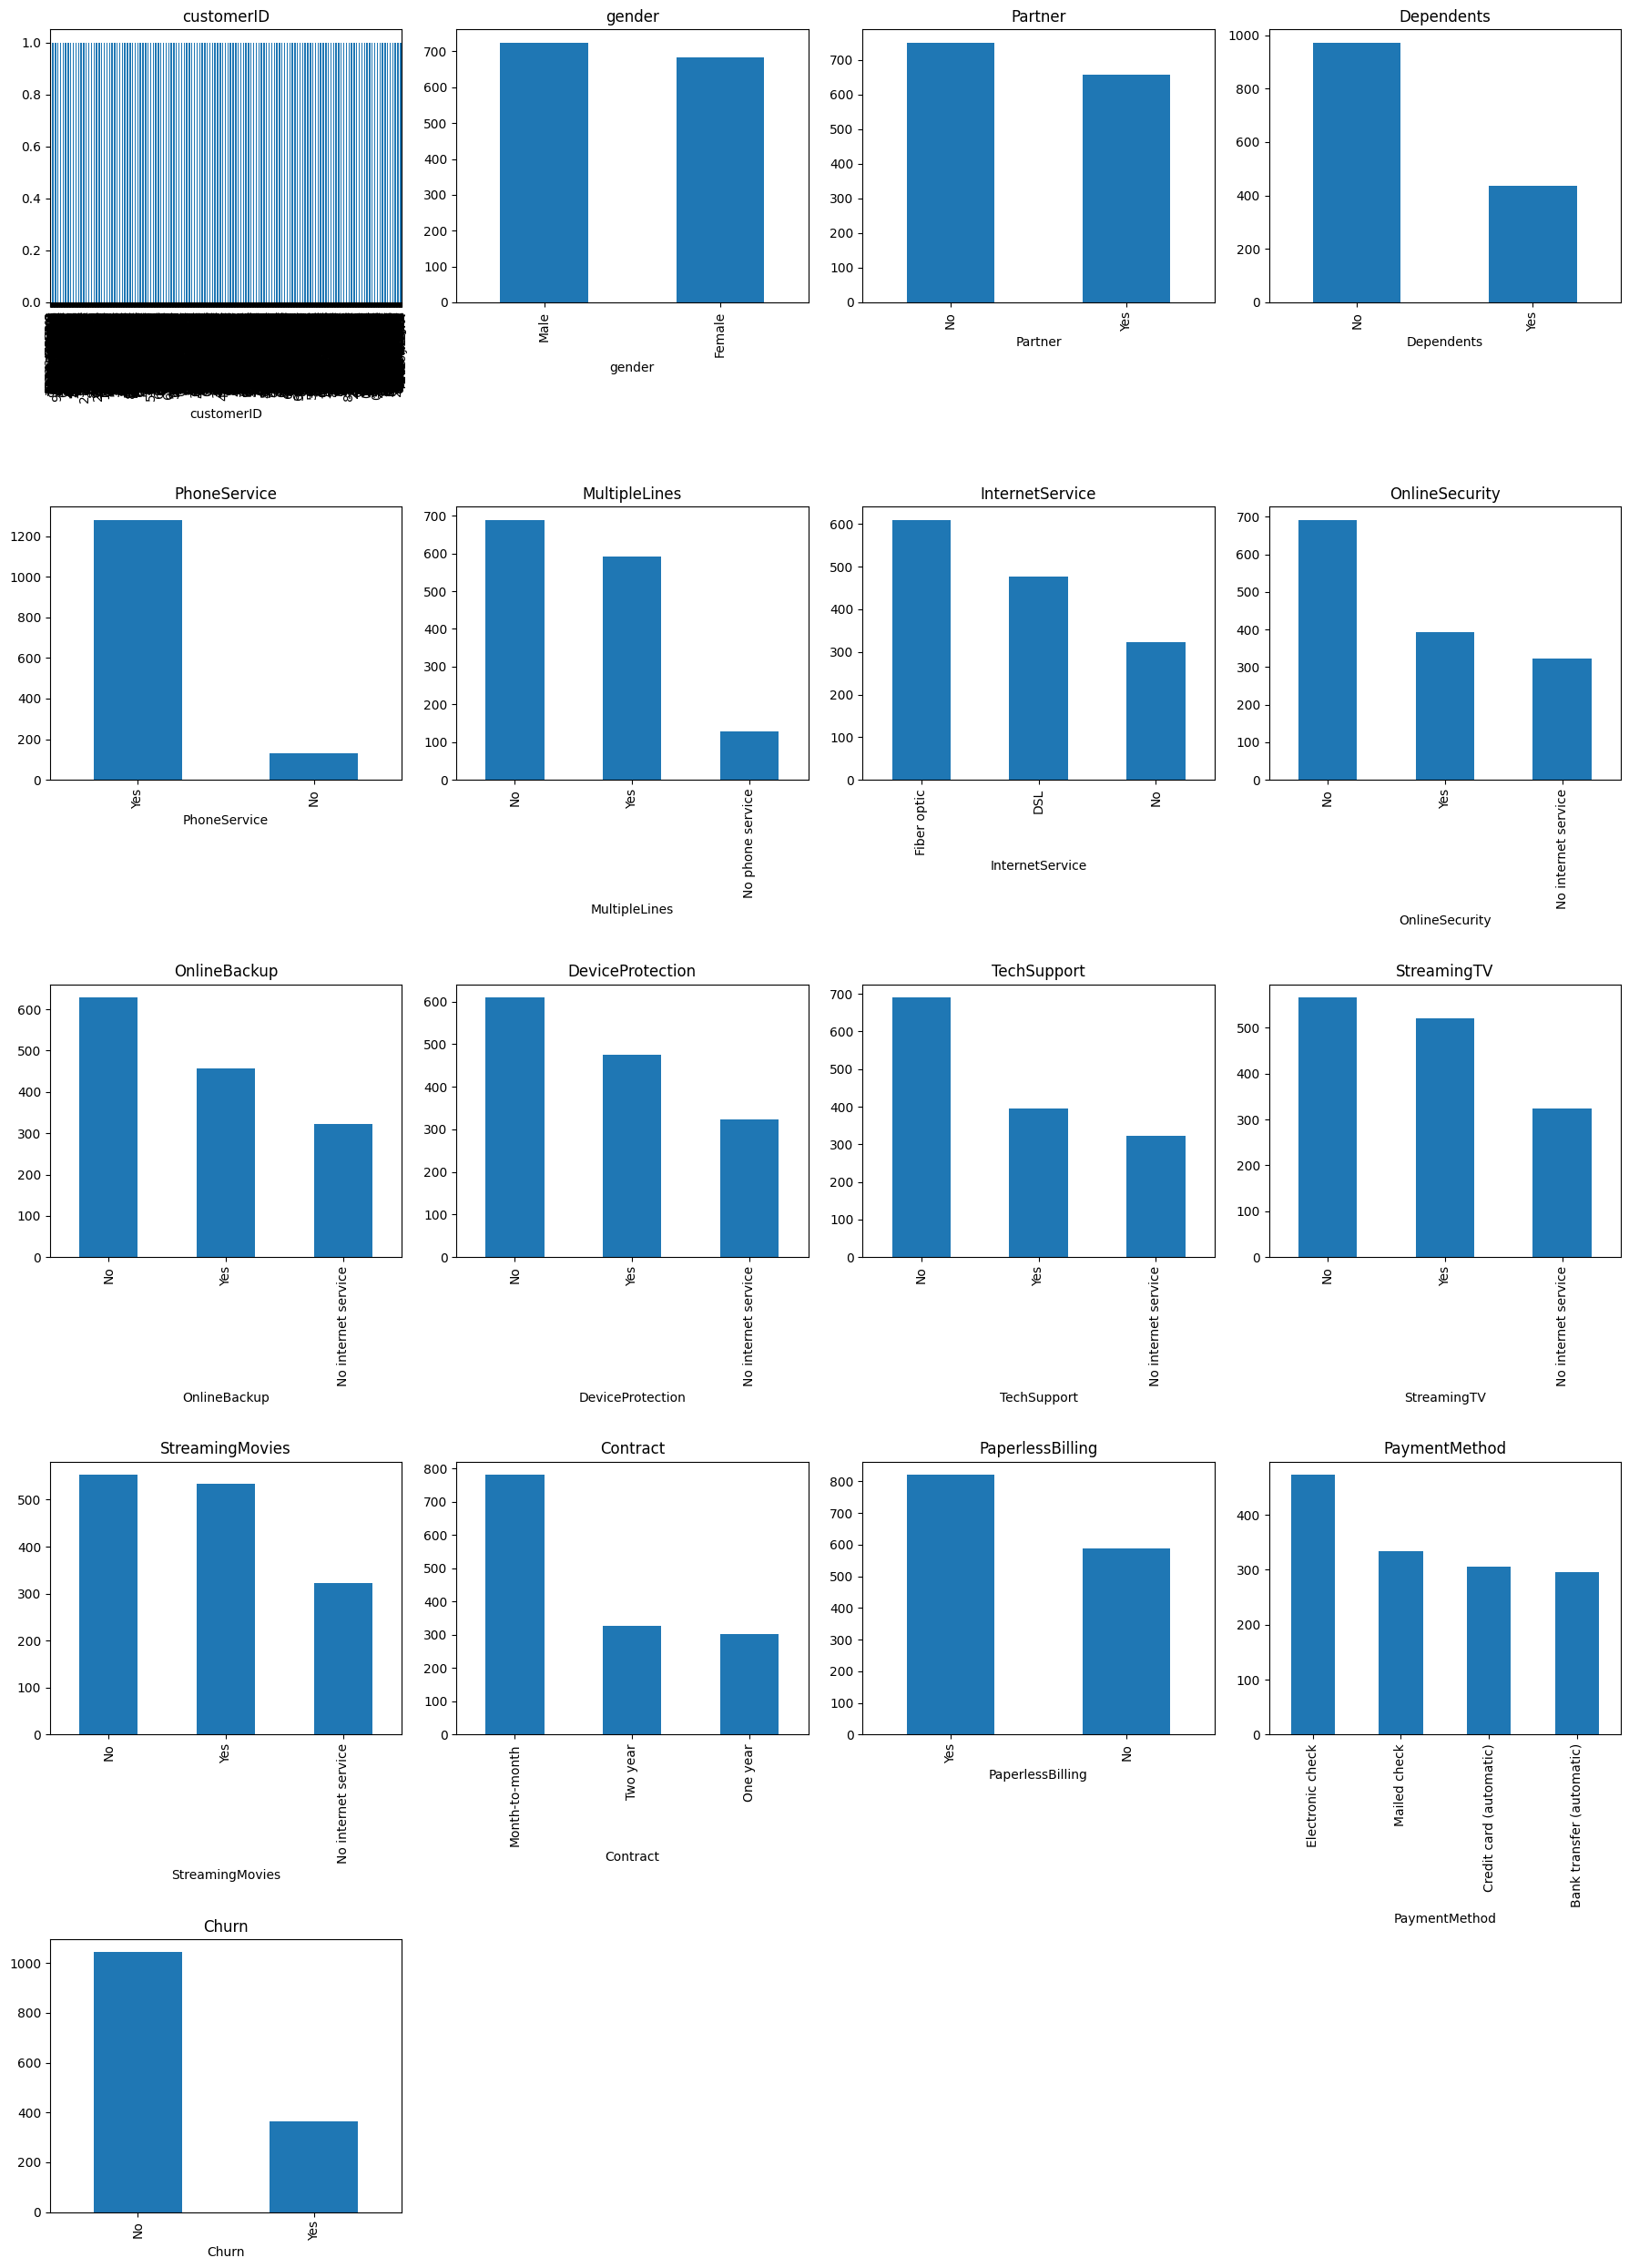

In [31]:
plt.figure(figsize=(18,25))

for i, col in enumerate(cat_cols, 1):

    plt.subplot(5, 4, i)

    test_df[col].value_counts().plot(kind='bar')

    plt.title(col)

plt.tight_layout()

plt.show()

#Outliers

In [32]:
train_df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,5634.000000,5634.000000,5634.000000,5634.000000
mean,0.159744,32.606851,65.490034,2238.250728
std,0.366401,24.614976,29.020760,2216.294428
min,0.000000,0.000000,18.250000,18.850000
25%,0.000000,9.000000,44.000000,446.062500
50%,0.000000,29.000000,70.650000,1396.450000
75%,0.000000,56.000000,89.100000,3590.537500
max,1.000000,72.000000,118.750000,8684.800000


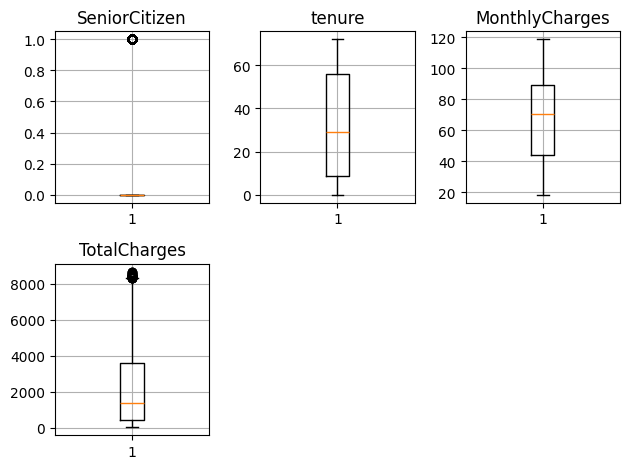

In [33]:
for i, col in enumerate(num_cols,1):
  plt.subplot(2,3,i)
  plt.boxplot(train_df[col])
  plt.title(col)
  plt.grid()


plt.tight_layout()
plt.show()

In [34]:
Q1 = train_df['TotalCharges'].quantile(0.25)

Q3 = train_df['TotalCharges'].quantile(0.75)

IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * IQR

lower_limit = Q1 - 1.5 * IQR

outliers = (
    (train_df['TotalCharges'] > upper_limit) |
    (train_df['TotalCharges'] < lower_limit)
)

outliers_df = train_df[outliers]


train_df = train_df[~outliers]

# Reset Index
train_df.reset_index(drop=True, inplace=True)

In [35]:
outlier_percentage=len(outliers_df)/len(train_df)* 100
outlier_percentage

0.42780748663101603

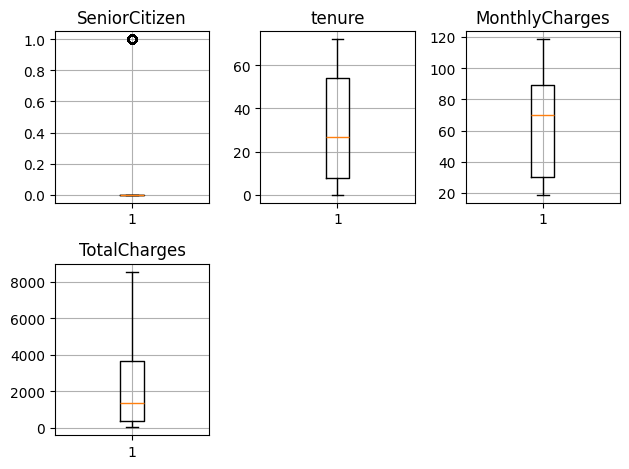

In [36]:
for i, col in enumerate(num_cols,1):
  plt.subplot(2,3,i)
  plt.boxplot(test_df[col])
  plt.title(col)
  plt.grid()


plt.tight_layout()
plt.show()

In [37]:
corr_matrix= train_df[num_cols].corr(method='pearson')
corr_matrix

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.021932,0.206955,0.101844
tenure,0.021932,1.000000,0.224140,0.795630
MonthlyCharges,0.206955,0.224140,1.000000,0.601904
TotalCharges,0.101844,0.795630,0.601904,1.000000


<Axes: >

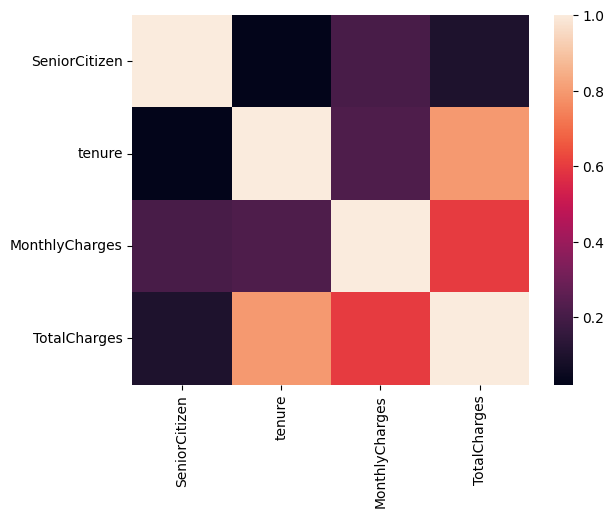

In [38]:
sns.heatmap(corr_matrix)

In [39]:
num_cols

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

In [40]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5610 entries, 0 to 5609
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5610 non-null   object 
 1   gender            5610 non-null   object 
 2   SeniorCitizen     5610 non-null   int64  
 3   Partner           5610 non-null   object 
 4   Dependents        5610 non-null   object 
 5   tenure            5610 non-null   int64  
 6   PhoneService      5610 non-null   object 
 7   MultipleLines     5610 non-null   object 
 8   InternetService   5610 non-null   object 
 9   OnlineSecurity    5610 non-null   object 
 10  OnlineBackup      5610 non-null   object 
 11  DeviceProtection  5610 non-null   object 
 12  TechSupport       5610 non-null   object 
 13  StreamingTV       5610 non-null   object 
 14  StreamingMovies   5610 non-null   object 
 15  Contract          5610 non-null   object 
 16  PaperlessBilling  5610 non-null   object 


In [41]:
train_df.drop('customerID', axis=1, inplace=True)

#Data Encoding

In [42]:
cat_cols = train_df.select_dtypes(include=['object']).columns

print(cat_cols)

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')


In [43]:
unique_values = train_df['gender'].unique()
print(unique_values)

['Female' 'Male']


In [44]:
unique_values = train_df['Partner'].unique()
print(unique_values)

['No' 'Yes']


In [45]:
unique_values = train_df['Dependents'].unique()
print(unique_values)

['No' 'Yes']


In [46]:
unique_values = train_df['PhoneService'].unique()
print(unique_values)

['Yes' 'No']


In [47]:
unique_values = train_df['MultipleLines'].unique()
print(unique_values)

['No' 'No phone service' 'Yes']


In [48]:
cat_cols = [
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaperlessBilling',
    'PaymentMethod',
    'Churn'
]

for col in cat_cols:

    print("Column Name :", col)

    print("Unique Values :", train_df[col].unique())

    print("-" * 50)

Column Name : gender
Unique Values : ['Female' 'Male']
--------------------------------------------------
Column Name : Partner
Unique Values : ['No' 'Yes']
--------------------------------------------------
Column Name : Dependents
Unique Values : ['No' 'Yes']
--------------------------------------------------
Column Name : PhoneService
Unique Values : ['Yes' 'No']
--------------------------------------------------
Column Name : MultipleLines
Unique Values : ['No' 'No phone service' 'Yes']
--------------------------------------------------
Column Name : InternetService
Unique Values : ['No' 'DSL' 'Fiber optic']
--------------------------------------------------
Column Name : OnlineSecurity
Unique Values : ['No internet service' 'No' 'Yes']
--------------------------------------------------
Column Name : OnlineBackup
Unique Values : ['No internet service' 'No' 'Yes']
--------------------------------------------------
Column Name : DeviceProtection
Unique Values : ['No internet service'

In [49]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cat_cols = [
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaperlessBilling',
    'PaymentMethod',
    'Churn'
]

for col in cat_cols:

    train_df[col] = le.fit_transform(train_df[col])

    test_df[col] = le.transform(test_df[col])

In [50]:
corr_matrix = train_df.corr()

In [51]:
train_df.head(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,0,0,35,1,0,2,1,1,1,1,1,1,1,0,3,20.75,700.45,0
1,0,0,0,0,28,0,1,0,0,0,2,2,0,0,0,1,3,35.75,961.40,0
2,1,0,0,0,56,1,2,1,0,2,0,0,2,2,0,0,2,98.60,5581.05,0
3,1,0,1,0,39,1,0,2,1,1,1,1,1,1,2,1,0,20.45,790.00,0
4,0,0,1,1,43,0,1,0,0,2,0,2,2,0,1,1,0,51.25,2151.60,0


In [52]:
corr_matrix

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
gender,1.000000,0.005869,0.014204,0.018888,0.008906,-0.011893,0.003940,-0.001534,-0.004322,-0.007552,0.007386,0.003934,-0.003663,-0.000610,0.006517,-0.012766,0.002376,-0.005834,-0.003487,-0.011669
SeniorCitizen,0.005869,1.000000,0.019891,-0.211785,0.021932,-0.001268,0.143371,-0.034083,-0.121385,-0.003024,-0.016131,-0.152714,0.028521,0.041796,-0.142035,0.139492,-0.040079,0.206955,0.101844,0.148627
Partner,0.014204,0.019891,1.000000,0.447302,0.378563,0.013778,0.139478,0.004492,0.144073,0.148516,0.165392,0.130249,0.136162,0.125830,0.294799,-0.024631,-0.159261,0.089381,0.310549,-0.156070
Dependents,0.018888,-0.211785,0.447302,1.000000,0.156374,-0.004941,-0.026989,0.049392,0.162986,0.095912,0.085142,0.129706,0.044485,0.020216,0.241623,-0.120657,-0.041317,-0.112337,0.058193,-0.171194
tenure,0.008906,0.021932,0.378563,0.156374,1.000000,0.002064,0.336892,-0.031097,0.315592,0.368758,0.365555,0.323489,0.283146,0.291486,0.672325,0.000497,-0.374161,0.224140,0.795630,-0.357632
PhoneService,-0.011893,-0.001268,0.013778,-0.004941,0.002064,1.000000,-0.021464,0.389175,-0.007531,0.026201,0.003737,-0.022928,0.045220,0.038717,-0.007397,0.019786,0.008802,0.238560,0.102014,0.015064
MultipleLines,0.003940,0.143371,0.139478,-0.026989,0.336892,-0.021464,1.000000,-0.112945,0.001268,0.117494,0.122073,0.004550,0.178549,0.181398,0.103523,0.167312,-0.173574,0.420563,0.441612,0.040116
InternetService,-0.001534,-0.034083,0.004492,0.049392,-0.031097,0.389175,-0.112945,1.000000,-0.029856,0.030551,0.040778,-0.029737,0.101015,0.095873,0.096555,-0.139572,0.092660,-0.309789,-0.177623,-0.051426
OnlineSecurity,-0.004322,-0.121385,0.144073,0.162986,0.315592,-0.007531,0.001268,-0.029856,1.000000,0.172509,0.159387,0.274898,0.030909,0.053841,0.361036,-0.156422,-0.097819,-0.056074,0.233304,-0.287799
OnlineBackup,-0.007552,-0.003024,0.148516,0.095912,0.368758,0.026201,0.117494,0.030551,0.172509,1.000000,0.179939,0.180988,0.141823,0.131362,0.284805,-0.018392,-0.124335,0.116902,0.363022,-0.192701


In [53]:
corr_matrix['Churn'].sort_values(ascending=False)

,Churn
Churn,1.000000
MonthlyCharges,0.193251
PaperlessBilling,0.190809
SeniorCitizen,0.148627
PaymentMethod,0.111045
MultipleLines,0.040116
PhoneService,0.015064
gender,-0.011669
StreamingTV,-0.039649
StreamingMovies,-0.042567


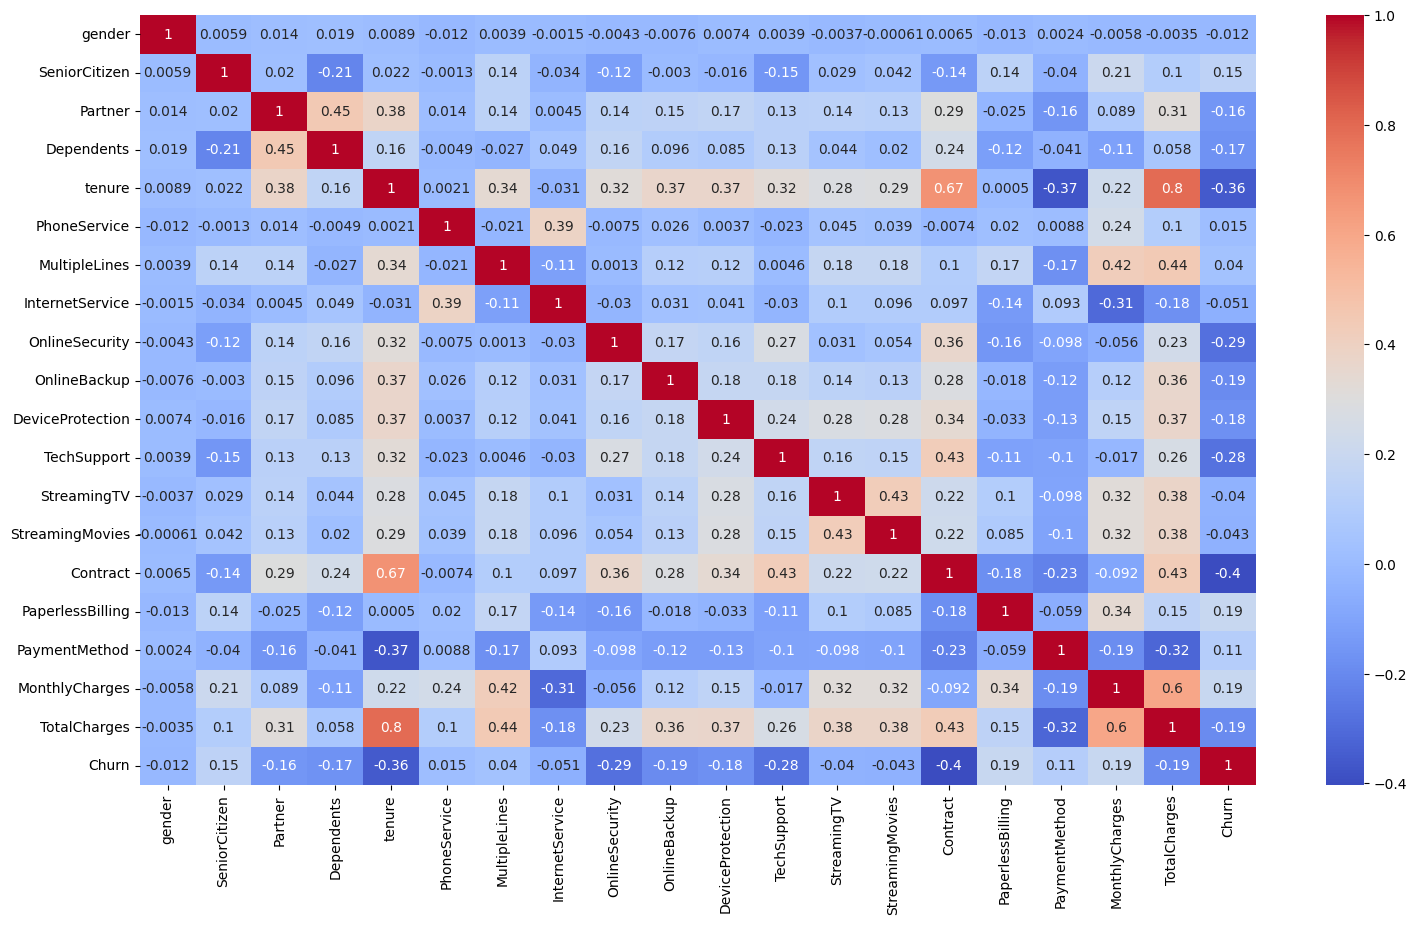

In [54]:
plt.figure(figsize=(18,10))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

plt.show()

#Feature Engineering

In [61]:
train_df['Tenure_Contract'] = (
    train_df['tenure'] * train_df['Contract']
)

test_df['Tenure_Contract'] = (
    test_df['tenure'] * test_df['Contract']
)

#Splitting

In [62]:
X = train_df.drop('Churn', axis=1)

y = train_df['Churn']

In [63]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [64]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

#Modeling

#LOGISTIC

In [65]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

In [66]:
from sklearn.metrics import accuracy_score

lr_accuracy = accuracy_score(y_test, y_pred_lr)

print(lr_accuracy)

0.785204991087344


Accuracy : 0.785204991087344
              precision    recall  f1-score   support

           0       0.82      0.89      0.85       792
           1       0.66      0.55      0.60       330

    accuracy                           0.79      1122
   macro avg       0.74      0.72      0.73      1122
weighted avg       0.78      0.79      0.78      1122



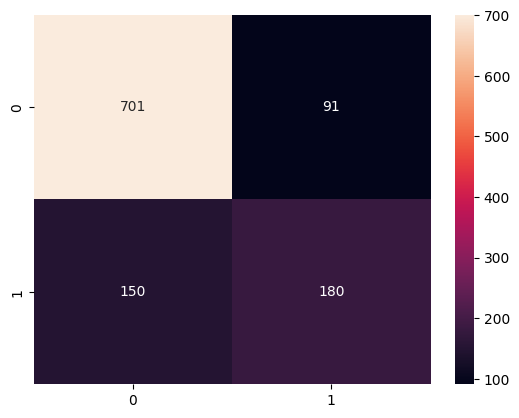

In [83]:
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("Accuracy :", accuracy_score(y_test, y_pred_lr))

print(classification_report(y_test, y_pred_lr))

cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt='d')

plt.show()

#KNN

In [68]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

Accuracy : 0.7397504456327986
              precision    recall  f1-score   support

           0       0.80      0.84      0.82       792
           1       0.56      0.51      0.53       330

    accuracy                           0.74      1122
   macro avg       0.68      0.67      0.68      1122
weighted avg       0.73      0.74      0.74      1122



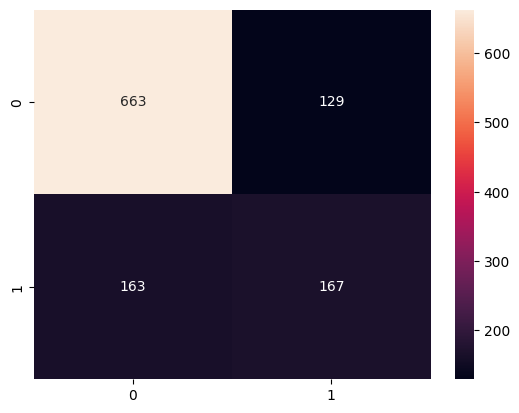

In [84]:
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

print("Accuracy :", accuracy_score(y_test, y_pred_knn))

print(classification_report(y_test, y_pred_knn))

cm = confusion_matrix(y_test, y_pred_knn)

sns.heatmap(cm, annot=True, fmt='d')

plt.show()

#SVM

In [70]:
from sklearn.svm import SVC

svc = SVC(kernel='rbf')

svc.fit(X_train_scaled, y_train)

y_pred_svc = svc.predict(X_test_scaled)

Accuracy : 0.7789661319073083
              precision    recall  f1-score   support

           0       0.81      0.91      0.85       792
           1       0.68      0.48      0.56       330

    accuracy                           0.78      1122
   macro avg       0.74      0.69      0.71      1122
weighted avg       0.77      0.78      0.77      1122



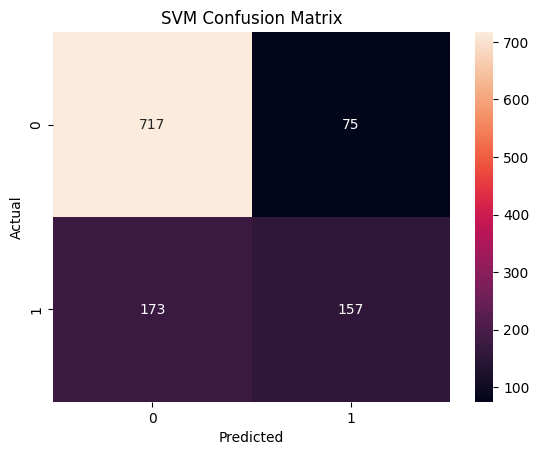

In [87]:

svc_accuracy = accuracy_score(y_test, y_pred_svc)

print("Accuracy :", svc_accuracy)

print(classification_report(y_test, y_pred_svc))

cm = confusion_matrix(y_test, y_pred_svc)

sns.heatmap(cm, annot=True, fmt='d')

plt.title("SVM Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

#DECISION TREE

In [76]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

Accuracy : 0.7165775401069518
              precision    recall  f1-score   support

           0       0.80      0.80      0.80       792
           1       0.52      0.52      0.52       330

    accuracy                           0.72      1122
   macro avg       0.66      0.66      0.66      1122
weighted avg       0.72      0.72      0.72      1122



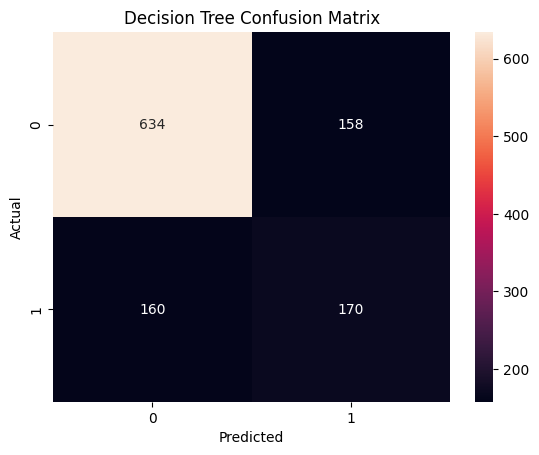

In [88]:
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Accuracy :", dt_accuracy)

print(classification_report(y_test, y_pred_dt))

cm = confusion_matrix(y_test, y_pred_dt)

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Decision Tree Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

#RANDOMFOREST

In [78]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

Accuracy : 0.7664884135472371
              precision    recall  f1-score   support

           0       0.80      0.89      0.84       792
           1       0.64      0.48      0.55       330

    accuracy                           0.77      1122
   macro avg       0.72      0.68      0.70      1122
weighted avg       0.75      0.77      0.76      1122



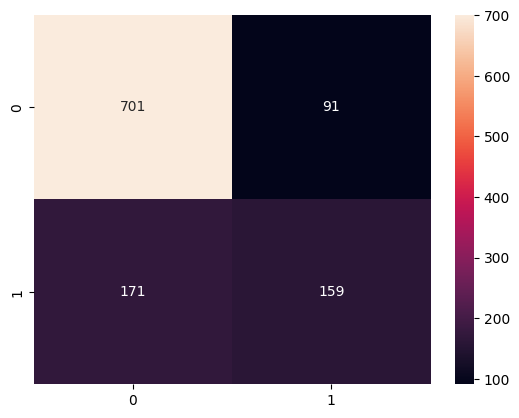

In [85]:
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d')

plt.show()

In [89]:
models = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'KNN',
        'SVM',
        'Decision Tree',
        'Random Forest'
    ],

    'Accuracy': [
        lr_accuracy,
        knn_accuracy,
        svc_accuracy,
        dt_accuracy,
        rf_accuracy
    ]
})

models

,Model,Accuracy
0,Logistic Regression,0.785205
1,KNN,0.739750
2,SVM,0.778966
3,Decision Tree,0.716578
4,Random Forest,0.766488


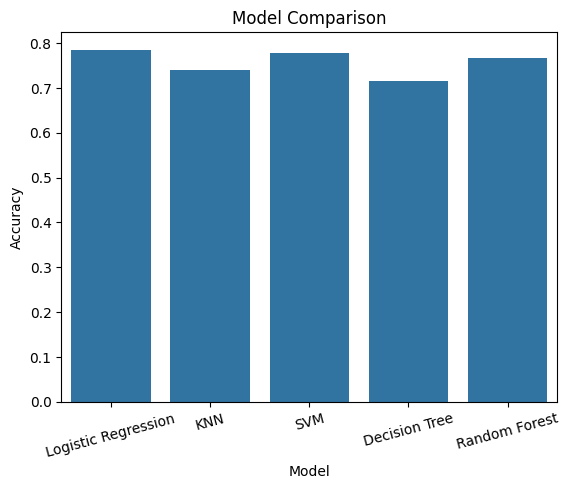

In [90]:
sns.barplot(
    x='Model',
    y='Accuracy',
    data=models
)

plt.xticks(rotation=15)

plt.title("Model Comparison")

plt.show()

#TUNNING

In [94]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs']
}

grid_lr = GridSearchCV(
    LogisticRegression(),
    param_grid,
    cv=5,
    scoring='accuracy'
)


grid_lr.fit(X_train_scaled, y_train)

print(grid_lr.best_params_)

print(grid_lr.best_score_)

{'C': 0.1, 'solver': 'lbfgs'}
0.801692352384712


In [95]:
best_lr = grid_lr.best_estimator_

y_pred_best_lr = best_lr.predict(X_test_scaled)

In [96]:
print("Accuracy :", accuracy_score(y_test, y_pred_best_lr))

print(classification_report(y_test, y_pred_best_lr))

Accuracy : 0.7887700534759359
              precision    recall  f1-score   support

           0       0.83      0.89      0.86       792
           1       0.67      0.55      0.60       330

    accuracy                           0.79      1122
   macro avg       0.75      0.72      0.73      1122
weighted avg       0.78      0.79      0.78      1122



#CONCLUSION

In this project, a customer churn prediction model was developed using machine learning techniques for a telecommunications company. The dataset was analyzed through EDA, and preprocessing steps such as handling missing values, outlier treatment, encoding categorical variables, and feature scaling were performed successfully.

Feature engineering techniques, including Customer Lifetime Value (CLV) and tenure-contract interaction features, were applied to improve the dataset representation.

Multiple machine learning models were trained and evaluated:

* Logistic Regression
* KNN
* SVM
* Decision Tree
* Random Forest

Among these models, Logistic Regression achieved the best performance with an accuracy of approximately 78.8%. Hyperparameter tuning using GridSearchCV further improved the model performance with the best parameters:


## Key Findings

* Customers with lower tenure were more likely to churn.
* Month-to-month contract customers showed higher churn rates.
* Higher monthly charges increased churn probability.
* Customers using support and security services were less likely to churn.

## Business Recommendations

* Provide retention offers for low-tenure customers.
* Encourage customers to adopt long-term contracts.
* Improve customer support and loyalty programs for high-risk customers.

